# Iris Dataset Classification
        {
            "cell_type": "code",
            "id": "#VSC-e56302cc",
            "metadata": {
                "language": "python"
            },
            "source": [
                "g = sns.pairplot(df, hue=\"species\", diag_kind=\"kde\")",
                "g.fig.suptitle('Pairplot of Iris features by Species', y=1.03)",
                "plt.show()"
            ]
        },
This dataset became a typical test case for many statistical classification techniques in machine learning such as support vector machines.

The dataset contains a set of 150 records under 5 attributes - Petal Length, Petal Width, Sepal Length, Sepal width and Class(Species).

##  Import dependencies

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# for preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#for evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

#for model validation
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold

## Dataset Loading and Exploration

In [2]:
df = pd.read_csv('iris-dataset.csv')

In [3]:
df 

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [6]:
df.shape

(150, 5)

In [7]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [9]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [46]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [45]:
print(df.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')


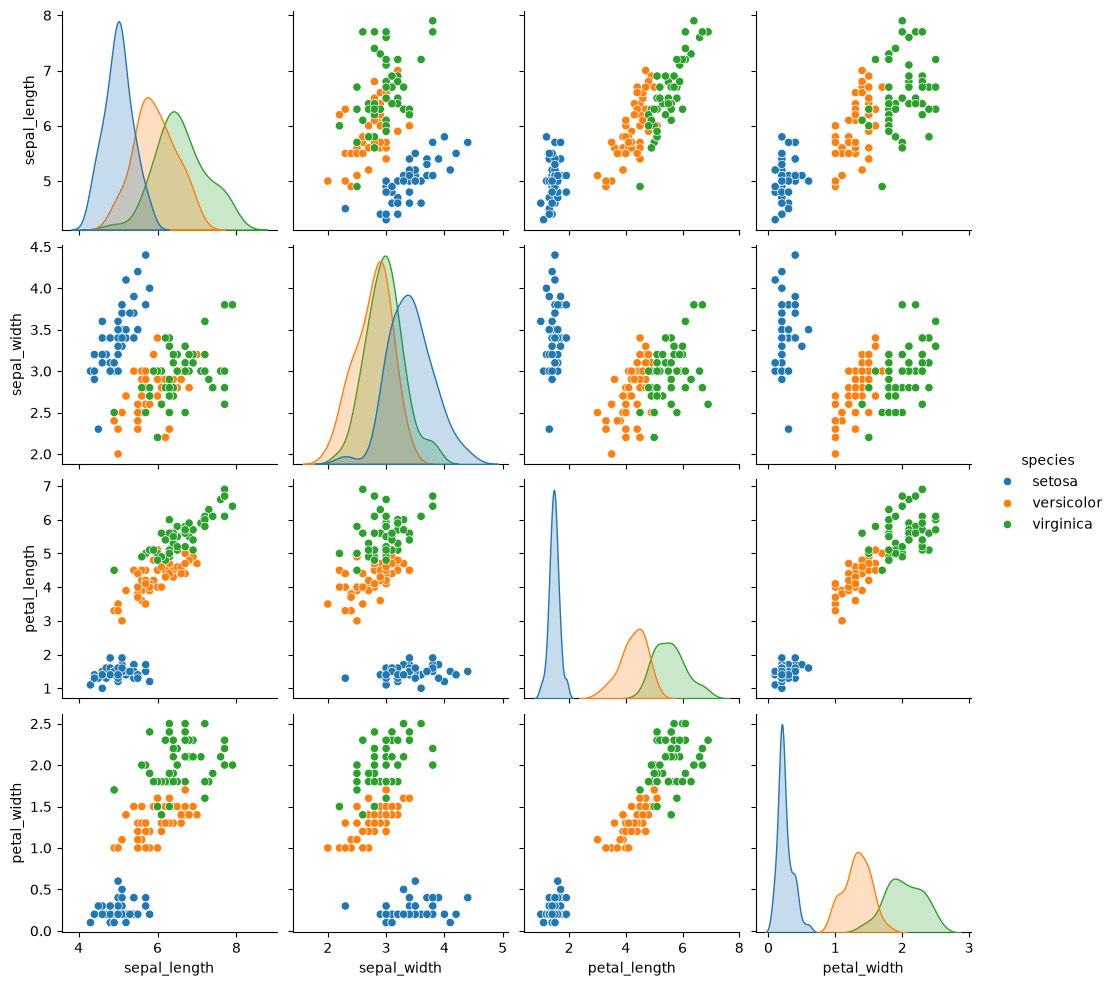

In [ ]:
g = sns.pairplot(df, hue="species", diag_kind="kde")
g.fig.suptitle('Pairplot of Iris features by Species', y=1.03)
plt.show()

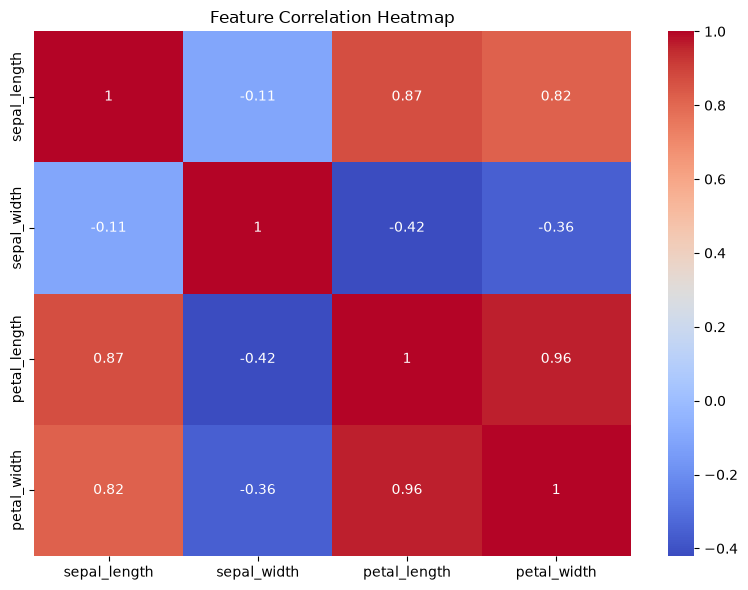

In [89]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Data Preprocessing

In [10]:
X = df.drop("species", axis=1)
y = df["species"]

### Dataset Splitting


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Feature Scaling

Since KNN and ANN depend on distance and gradient optimization, we need to scale the data.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

### KNN Classification

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)



,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['setosa','versicolor','virginica']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [15]:
knn_pred = knn.predict(X_test_scaled)

In [16]:
knn_pred[0:5]

array(['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa'],
      dtype=object)

In [32]:
y_test.head()

38         setosa
127     virginica
57     versicolor
93     versicolor
42         setosa
Name: species, dtype: str

In [34]:
dfData = {'Y Test' : y_test.values,
          'Predict' : knn_pred}

In [35]:
result = pd.DataFrame(dfData)
result

,Y Test,Predict
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


### Decision Tree Classification

In [17]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)



,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [18]:
dt_pred = dt.predict(X_test)

In [47]:
dt_pred[0:5]   

array(['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa'],
      dtype=object)

In [48]:
dfData = {'Y Test' : y_test.values,
          'Predict' : dt_pred}

In [49]:
result = pd.DataFrame(dfData)
result

,Y Test,Predict
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


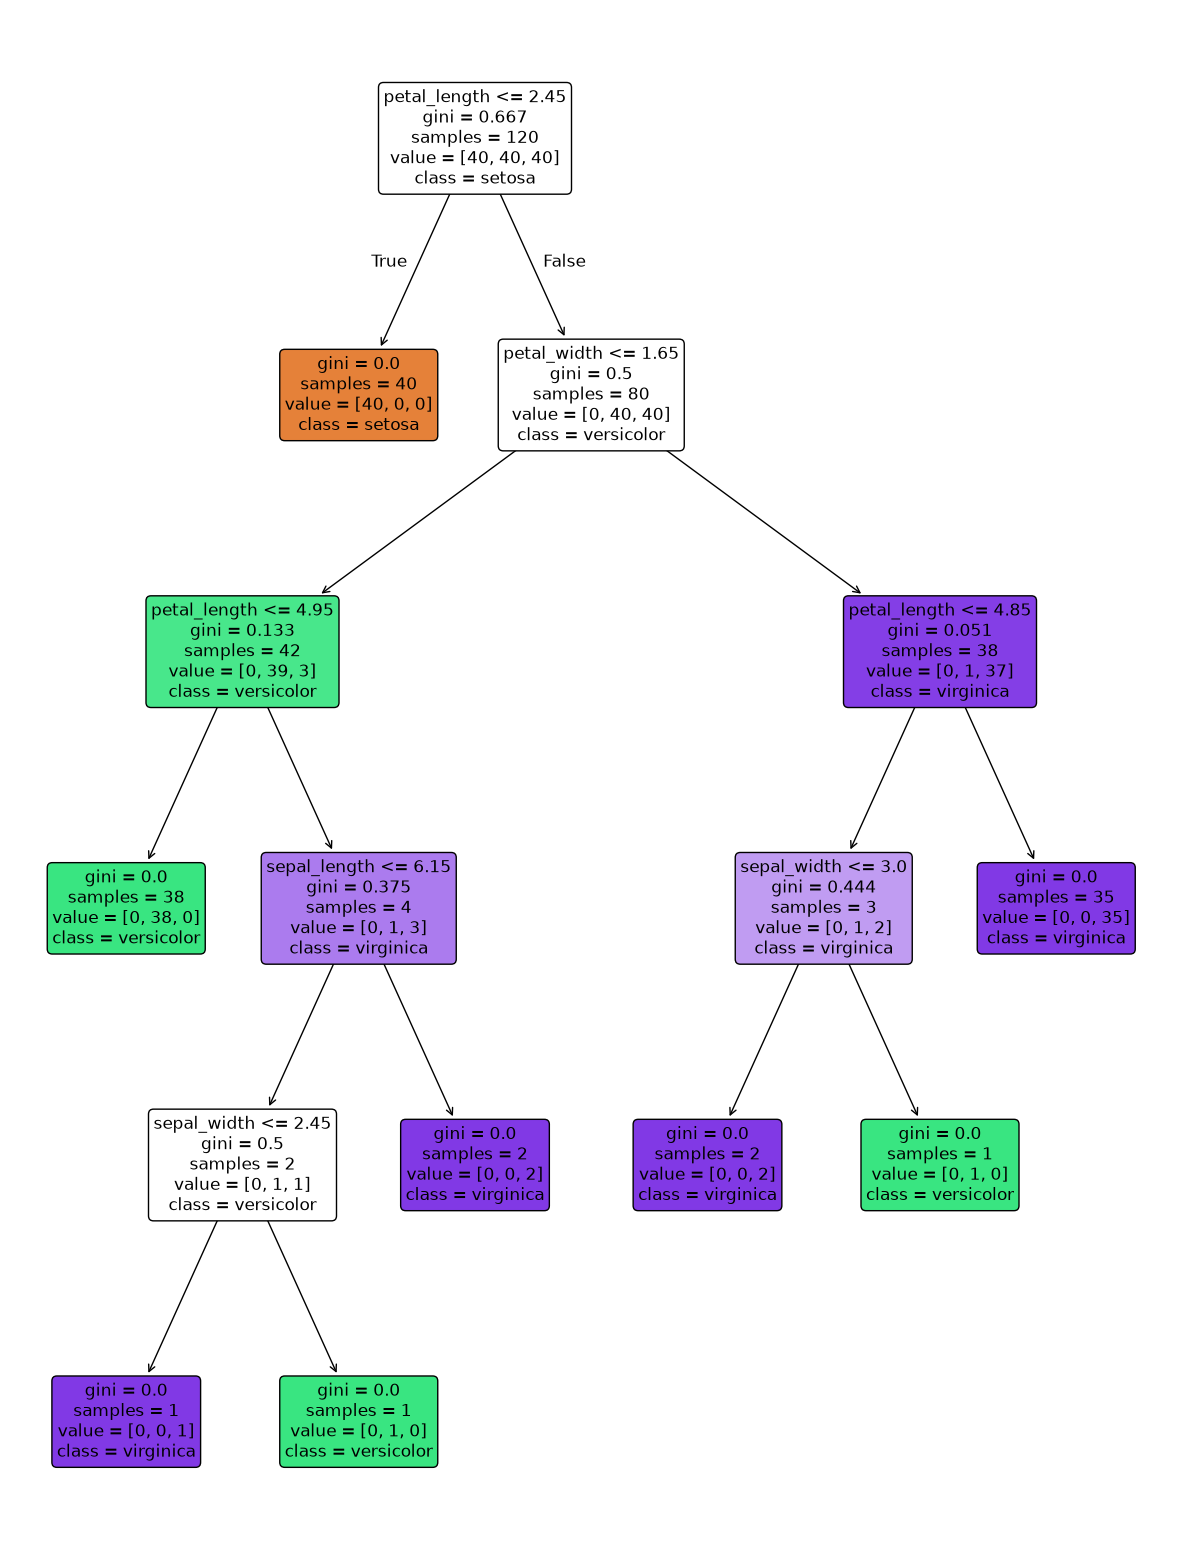

In [38]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 20))

plot_tree(dt, 
          feature_names=X.columns, 
          class_names=dt.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=12)

plt.show()

### Naive Bayes

In [19]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)



,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[40.,40.,40.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.33,0.33,0.33]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[<U10](3,)","['setosa','versicolor','virginica']"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,3.098e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['sepal_length','sepal_width','petal_length','petal_width']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 4)","[[4.99,3.4 ,1.48,0.25], [5.93,2.75,4.25,1.32], [6.61,2.98,5.58,2.04]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 4)","[[0.09,0.16,0.03,0.01], [0.22,0.09,0.19,0.03], [0.46,0.12,0.32,0.07]]"


In [20]:
nb_pred = nb.predict(X_test)

In [50]:
nb_pred[0:5]

array(['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa'],
      dtype='<U10')

In [ ]:
dfData = {'Y Test' : y_test.values,
          'Predict' : nb_pred}

In [51]:
result = pd.DataFrame(dfData)
result

,Y Test,Predict
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


### Artificial Neural Network(ANN)

In [81]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=2000,
    
    random_state=42
)

ann.fit(X_train_scaled, y_train)

ann_pred = ann.predict(X_test_scaled)

In [52]:
ann_pred[0:5]

array(['setosa', 'virginica', 'versicolor', 'versicolor', 'setosa'],
      dtype='<U10')

In [53]:
dfData = {'Y Test' : y_test.values,
          'Predict' : ann_pred}

In [54]:
result = pd.DataFrame(dfData)
result

,Y Test,Predict
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


## Model Evaluation

In [39]:
def evaluate_model(y_true, y_pred, model_name):

    print("="*40)
    print(model_name)
    print("="*40)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))

    labels = sorted(set(y_true) | set(y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    print("\nConfusion Matrix")
    print(cm)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.tight_layout()
    plt.show()

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

### KNN

KNN
Accuracy : 0.9333333333333333
Precision: 0.9444444444444445
Recall   : 0.9333333333333333
F1 Score : 0.9326599326599326

Confusion Matrix
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


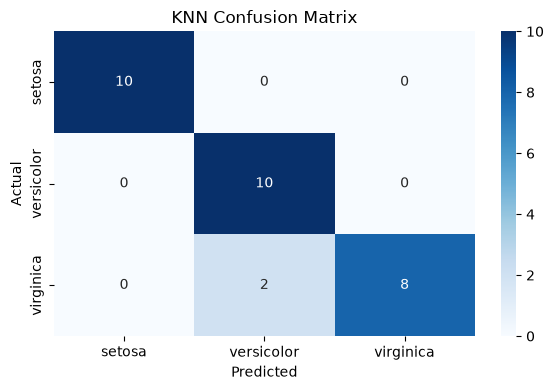


Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [97]:
evaluate_model(y_test, knn_pred, "KNN")


### Decision Tree

Decision Tree
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1 Score : 0.9333333333333333

Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


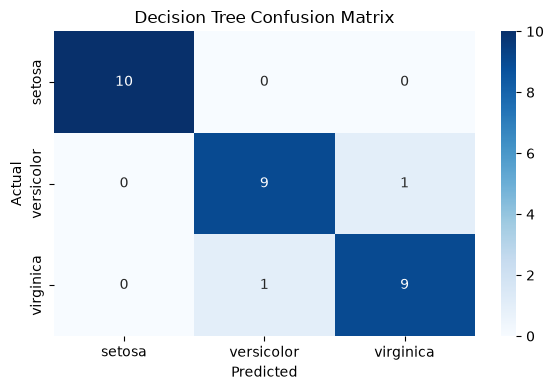


Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [41]:
evaluate_model(y_test, dt_pred, "Decision Tree")


### Naive Bayes

Naive Bayes
Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667
F1 Score : 0.9665831244778613

Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


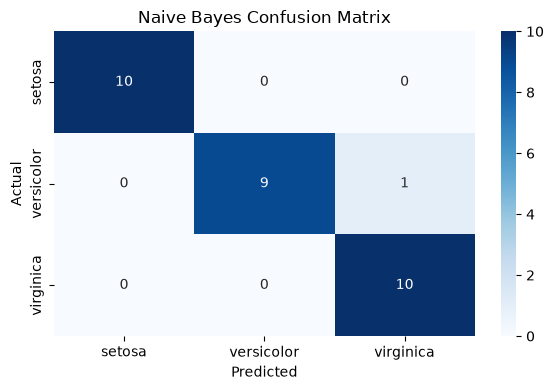


Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [42]:
evaluate_model(y_test, nb_pred, "Naive Bayes")


### ANN

Artificial Neural Network
Accuracy : 0.9666666666666667
Precision: 0.9696969696969696
Recall   : 0.9666666666666667
F1 Score : 0.9665831244778613

Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


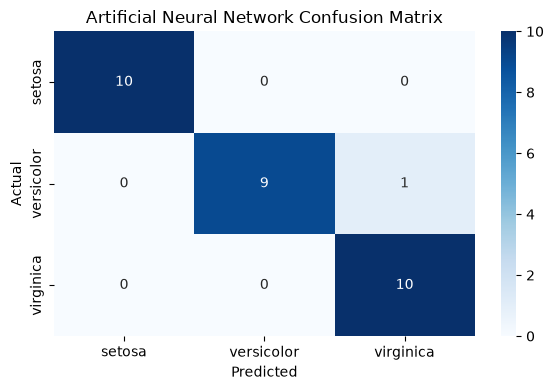


Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [82]:
evaluate_model(y_test, ann_pred, "Artificial Neural Network")

## Model Validation (5-fold Cross validation)

### KNN

In [56]:
knn_scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    scaler.fit_transform(X),
    y,
    cv=5
)


In [57]:
print("===== KNN 5-Fold Cross Validation Results =====\n")

for i, score in enumerate(knn_scores, start=1):
    print(f"Fold {i} Accuracy : {score:.4f} ({score*100:.2f}%)")

print("\n--------------------------------")
print(f"Mean Accuracy     : {np.mean(knn_scores):.4f} ({np.mean(knn_scores)*100:.2f}%)")
print(f"Standard Deviation: {np.std(knn_scores):.4f}")

===== KNN 5-Fold Cross Validation Results =====

Fold 1 Accuracy : 0.9667 (96.67%)
Fold 2 Accuracy : 0.9667 (96.67%)
Fold 3 Accuracy : 0.9333 (93.33%)
Fold 4 Accuracy : 0.9333 (93.33%)
Fold 5 Accuracy : 1.0000 (100.00%)

--------------------------------
Mean Accuracy     : 0.9600 (96.00%)
Standard Deviation: 0.0249


### Decision Tree

In [58]:
dt_scores = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X,
    y,
    cv=5
)



In [59]:
print("===== Decision Tree 5-Fold Cross Validation Results =====\n")

for i, score in enumerate(dt_scores, start=1):
    print(f"Fold {i} Accuracy : {score:.4f} ({score*100:.2f}%)")

print("\n--------------------------------")
print(f"Mean Accuracy     : {np.mean(dt_scores):.4f} ({np.mean(dt_scores)*100:.2f}%)")
print(f"Standard Deviation: {np.std(dt_scores):.4f}")

===== Decision Tree 5-Fold Cross Validation Results =====

Fold 1 Accuracy : 0.9667 (96.67%)
Fold 2 Accuracy : 0.9667 (96.67%)
Fold 3 Accuracy : 0.9000 (90.00%)
Fold 4 Accuracy : 0.9333 (93.33%)
Fold 5 Accuracy : 1.0000 (100.00%)

--------------------------------
Mean Accuracy     : 0.9533 (95.33%)
Standard Deviation: 0.0340


### Naive Bayes

In [60]:
nb_scores = cross_val_score(
    GaussianNB(),
    X,
    y,
    cv=5
)



In [61]:
print("===== Naive Bayes 5-Fold Cross Validation Results =====\n")

for i, score in enumerate(nb_scores, start=1):
    print(f"Fold {i} Accuracy : {score:.4f} ({score*100:.2f}%)")

print("\n--------------------------------")
print(f"Mean Accuracy     : {np.mean(nb_scores):.4f} ({np.mean(nb_scores)*100:.2f}%)")
print(f"Standard Deviation: {np.std(nb_scores):.4f}")

===== Naive Bayes 5-Fold Cross Validation Results =====

Fold 1 Accuracy : 0.9333 (93.33%)
Fold 2 Accuracy : 0.9667 (96.67%)
Fold 3 Accuracy : 0.9333 (93.33%)
Fold 4 Accuracy : 0.9333 (93.33%)
Fold 5 Accuracy : 1.0000 (100.00%)

--------------------------------
Mean Accuracy     : 0.9533 (95.33%)
Standard Deviation: 0.0267


### ANN

In [78]:
ann_scores = cross_val_score(
    MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000, random_state=42),
    scaler.fit_transform(X),
    y,
    cv=5
)



In [79]:
print("===== ANN 5-Fold Cross Validation Results =====\n")

for i, score in enumerate(ann_scores, start=1):
    print(f"Fold {i} Accuracy : {score:.4f} ({score*100:.2f}%)")

print("\n--------------------------------")
print(f"Mean Accuracy     : {np.mean(ann_scores):.4f} ({np.mean(ann_scores)*100:.2f}%)")
print(f"Standard Deviation: {np.std(ann_scores):.4f}")

===== ANN 5-Fold Cross Validation Results =====

Fold 1 Accuracy : 1.0000 (100.00%)
Fold 2 Accuracy : 0.9667 (96.67%)
Fold 3 Accuracy : 0.9667 (96.67%)
Fold 4 Accuracy : 0.9333 (93.33%)
Fold 5 Accuracy : 0.9667 (96.67%)

--------------------------------
Mean Accuracy     : 0.9667 (96.67%)
Standard Deviation: 0.0211


## Model Comparison and Interpretation

### InterpretationThe evaluation metrics show that Naive Bayes and ANN achieved the best overall performance on the test set, each reaching 96.67% accuracy. Their strong weighted precision and recall values indicate that these models are correctly identifying the Iris species while keeping both false positives and false negatives low.KNN and Decision Tree also perform well but are slightly behind the top models with 93.33% test accuracy. The Decision Tree shows the highest cross-validation standard deviation, which means it is more sensitive to the choice of training data and less stable than ANN or Naive Bayes.The cross-validation results support ANN as the most reliable choice because it combines a high mean accuracy (96.67%) with the lowest variability across folds (standard deviation 0.0211). KNN has a solid average CV score as well, but its larger variation suggests it may be less consistent on unseen data.Overall, ANN is the best balanced model for this Iris dataset, with Naive Bayes as a close second. KNN and Decision Tree remain useful alternatives, but they may benefit from additional tuning or ensemble methods for more stable performance.

### Comparison Table

| Model | Test Accuracy | Precision | Recall | F1 Score | Mean CV Accuracy | CV Std |
|---|---:|---:|---:|---:|---:|---:|
| KNN | 0.9333 | 0.9444 | 0.9333 | 0.9327 | 0.9600 | 0.0249 |
| Decision Tree | 0.9333 | 0.9333 | 0.9333 | 0.9333 | 0.9533 | 0.0340 |
| Naive Bayes | 0.9667 | 0.9697 | 0.9667 | 0.9666 | 0.9533 | 0.0267 |
| ANN | 0.9667 | 0.9697 | 0.9667 | 0.9666 | 0.9667 | 0.0211 |

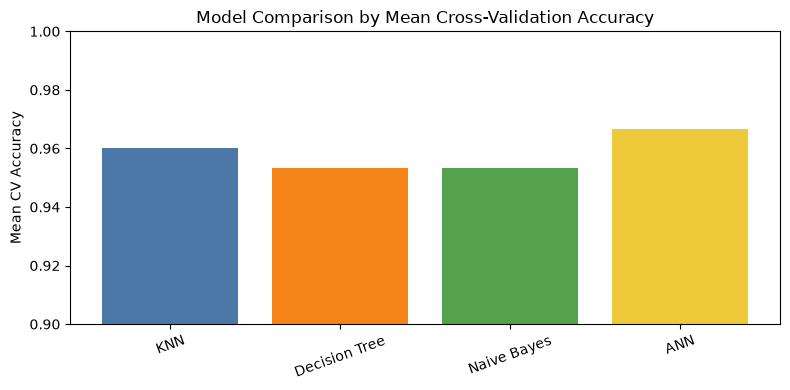

In [100]:
import matplotlib.pyplot as plt
import pandas as pd

comparison_table = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Naive Bayes', 'ANN'],
    'Mean CV Accuracy': [0.9600, 0.9533, 0.9533, 0.9667]
})

plt.figure(figsize=(8, 4))
plt.bar(comparison_table['Model'], comparison_table['Mean CV Accuracy'], color=['#4C78A8', '#F58518', '#54A24B', '#EECA3B'])
plt.title('Model Comparison by Mean Cross-Validation Accuracy')
plt.ylabel('Mean CV Accuracy')
plt.ylim(0.90, 1.00)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

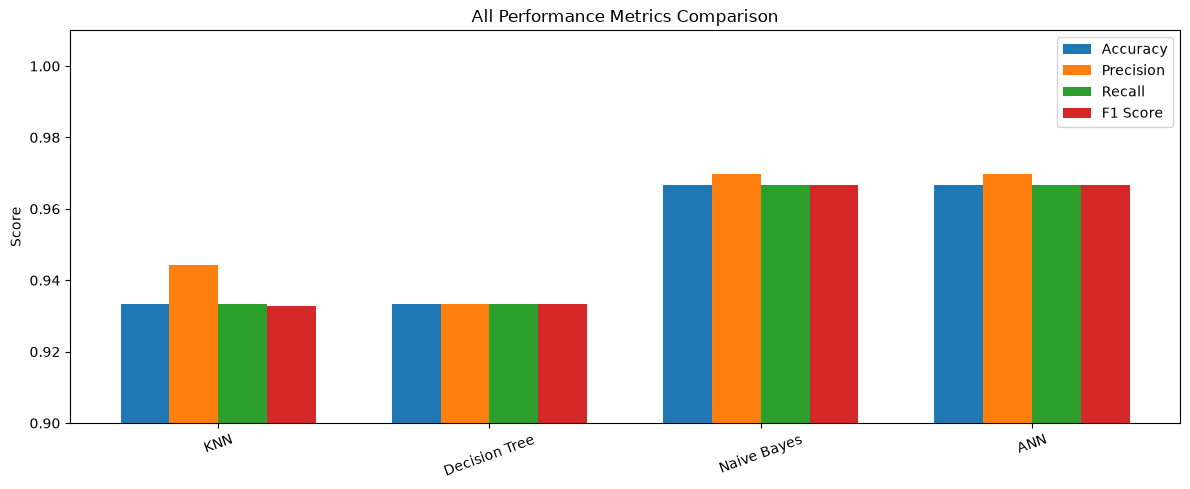

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Naive Bayes', 'ANN'],
    'Accuracy': [0.9333, 0.9333, 0.9667, 0.9667],
    'Precision': [0.9444, 0.9333, 0.9697, 0.9697],
    'Recall': [0.9333, 0.9333, 0.9667, 0.9667],
    'F1 Score': [0.9327, 0.9333, 0.9666, 0.9666]
})

metrics_long = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 5))

x = np.arange(len(metrics_df))
width = 0.18

for i, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1 Score']):
    values = metrics_df[metric].values
    plt.bar(x + i * width, values, width=width, label=metric)

plt.xticks(x + 1.5 * width, metrics_df['Model'], rotation=20)
plt.title('All Performance Metrics Comparison')
plt.ylabel('Score')
plt.ylim(0.90, 1.01)
plt.legend()
plt.tight_layout()
plt.show()